Enter Z component to plot (xx, xy, xz, yx, yy, yz, zx, zy, zz): xx


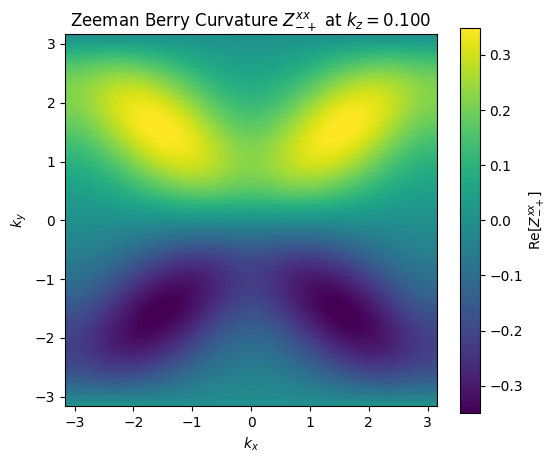

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# ---------------- Pauli matrices ----------------
sx = np.array([[0, 1], [1, 0]], dtype=complex)
sy = np.array([[0, -1j], [1j, 0]], dtype=complex)
sz = np.array([[1, 0], [0, -1]], dtype=complex)
sigma0 = np.eye(2, dtype=complex)

# ---------------- Model parameters ----------------
gamma = 1.5
t = 1.0
tx = 0.5
m = 2.0
k0 = np.pi / 2

# ---------------- Hamiltonian components ----------------
def N0_of_k(kx, ky, kz):
    return gamma * (np.cos(2*kx) - np.cos(k0)) * (np.cos(kz) - np.cos(k0))

def Nx_of_k(kx, ky, kz):
    return m * (1 - np.cos(kz)**2 - np.cos(ky)) + 2.0 * tx * (np.cos(kx) - np.cos(k0))

def Ny_of_k(kx, ky, kz):
    return -2.0 * t * np.sin(ky)

def Nz_of_k(kx, ky, kz):
    return -2.0 * t * np.cos(kz)

def H_k(kx, ky, kz):
    Nx = Nx_of_k(kx, ky, kz)
    Ny = Ny_of_k(kx, ky, kz)
    Nz = Nz_of_k(kx, ky, kz)
    N0 = N0_of_k(kx, ky, kz)
    H = Nx * sx + Ny * sy + Nz * sz + N0 * sigma0
    return H, Nx, Ny, Nz, N0

# ---------------- Derivatives of H ----------------
def dH_dkx(kx, ky, kz, dk=1e-5):
    H_plus, *_ = H_k(kx + dk, ky, kz)
    H_minus, *_ = H_k(kx - dk, ky, kz)
    return (H_plus - H_minus) / (2 * dk)

def dH_dky(kx, ky, kz, dk=1e-5):
    H_plus, *_ = H_k(kx, ky + dk, kz)
    H_minus, *_ = H_k(kx, ky - dk, kz)
    return (H_plus - H_minus) / (2 * dk)

def dH_dkz(kx, ky, kz, dk=1e-5):
    H_plus, *_ = H_k(kx, ky, kz + dk)
    H_minus, *_ = H_k(kx, ky, kz - dk)
    return (H_plus - H_minus) / (2 * dk)

# ---------------- Zeeman Berry Curvature ----------------
def zeeman_Z_components(kx, ky, kz, dk=1e-5):
    H, _, _, _, _ = H_k(kx, ky, kz)
    evals, evecs = np.linalg.eigh(H)
    u_minus = evecs[:, 0]
    u_plus  = evecs[:, 1]
    E_minus, E_plus = evals

    # Derivative matrices
    dHx = dH_dkx(kx, ky, kz, dk)
    dHy = dH_dky(kx, ky, kz, dk)
    dHz = dH_dkz(kx, ky, kz, dk)

    # Interband position matrix elements (Hellmann–Feynman)
    r_x_mp = 1j * np.vdot(u_minus, dHx @ u_plus) / (E_plus - E_minus)
    r_y_mp = 1j * np.vdot(u_minus, dHy @ u_plus) / (E_plus - E_minus)
    r_z_mp = 1j * np.vdot(u_minus, dHz @ u_plus) / (E_plus - E_minus)

    r_x_pm = np.conjugate(r_x_mp)
    r_y_pm = np.conjugate(r_y_mp)
    r_z_pm = np.conjugate(r_z_mp)

    # Spin matrices
    sigma_list = [sx, sy, sz]
    r_list = [(r_x_mp, r_x_pm), (r_y_mp, r_y_pm), (r_z_mp, r_z_pm)]
    Z = np.zeros((3, 3), dtype=complex)  # αβ tensor


    for a in range(3):
        for b in range(3):
            sigma_pm = np.vdot(u_plus, sigma_list[b] @ u_minus)
            sigma_mp = np.vdot(u_minus, sigma_list[b] @ u_plus)
            r_mp, r_pm = r_list[a]
            Z[a, b] = 1j * (r_mp * sigma_pm - r_pm * sigma_mp)

    return Z  # shape (3,3)

# ---------------- Grid Computation ----------------
N = 150
kx_vals = np.linspace(-np.pi, np.pi, N)
ky_vals = np.linspace(-np.pi, np.pi, N)
kz_fixed = 0.1

# --- Input which component to plot ---
component = input("Enter Z component to plot (xx, xy, xz, yx, yy, yz, zx, zy, zz): ").lower()

# Map input to indices
index_map = {'x': 0, 'y': 1, 'z': 2}
a, b = component[0], component[1]
i, j = index_map[a], index_map[b]

Zcomp = np.zeros((N, N))

for ix, kx in enumerate(kx_vals):
    for iy, ky in enumerate(ky_vals):
        Z = zeeman_Z_components(kx, ky, kz_fixed)
        Zcomp[ix, iy] = np.real(Z[i, j])  # you can also use np.imag(Z[i,j]) if you prefer

# ---------------- Plot ----------------
vmax = np.nanpercentile(Zcomp, 99.5)

plt.figure(figsize=(6, 5))
plt.pcolormesh(kx_vals, ky_vals, Zcomp, shading='auto')
plt.clim(-vmax, vmax)
plt.colorbar(label=fr'$\mathrm{{Re}}[Z_{{-+}}^{{{component}}}]$')
plt.title(fr'Zeeman Berry Curvature $Z_{{-+}}^{{{component}}}$ at $k_z = {kz_fixed:.3f}$')
plt.xlabel(r'$k_x$')
plt.ylabel(r'$k_y$')
plt.gca().set_aspect('equal')
plt.show()
